# RIM Spread Analysis  
**Re_smooth (Blume β + CAPM) vs TTM ROE → rim_spread_smooth**

## 처리 흐름
```
① DB (beta_1250)          → Blume smoothing → β_adj = 0.67×β + 0.33×1.0
② DB (rf_5y)  + FRED 보완 → rf
③ DB (E_Rm_5y)+ yf  보완  → E_Rm_adj (ERP floor 6% 적용)
④ Re_smooth = rf + β_adj × (E_Rm_adj - rf)
⑤ FMP 분기 IS+BS          → TTM ROE
⑥ rim_spread_smooth = TTM_ROE - Re_smooth
⑦ DB upsert: Re_smooth / roe_ttm / rim_spread_smooth
```


## 1. 경로 설정

In [1]:
import sys, os
from pathlib import Path

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] 자동 감지: {root}")
            return root
    for c in _CANDIDATE_ROOTS:
        if os.path.isdir(c) and os.path.isdir(os.path.join(c, "DATA")):
            if c not in sys.path:
                sys.path.insert(0, c)
            print(f"[PATH] 후보 경로: {c}")
            return c
    raise EnvironmentError("DATA 폴더를 찾을 수 없습니다.")

_ROOT = _setup_path()


[PATH] 자동 감지: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy


## 2. 라이브러리 & 설정 상수

In [2]:
import math, time, warnings, gc
import requests
import numpy as np
import pandas as pd
import pymysql
import FinanceDataReader as fdr
from datetime import datetime
from typing import Optional, Dict, Any, List, Tuple
warnings.filterwarnings('ignore')

from DATA.config import get_db_info, get_engine
from DATA.stock_invest_function import get_db_host
from DATA.us_target_ticker_list_2000 import ticker_list as US_TICKER_LIST

# ── API 키 ───────────────────────────────────────────────────────
FMP_API_KEY  = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"
FRED_API_KEY = "81ada9c572f7d710dbc61f035556cbd7"

# ── DB / 테이블 ──────────────────────────────────────────────────
TABLE_RESULT = "us_required_return_result"
TABLE_PRICE  = "us_stock_daily_market_cap"
PRICE_IND    = "close_price"
DEFAULT_PORT = 3307

# ── 모델 파라미터 ────────────────────────────────────────────────
BLUME_W      = 0.67    # Blume smoothing 원시 베타 가중치
ERP_FLOOR    = 0.06    # ERP 하한 6%
ERP_MIN_GAP  = 0.01    # E_Rm - rf < 1% 이면 floor 적용

# ── 분석 대상 ────────────────────────────────────────────────────
TICKERS    = ['NVDA','GOOG','AAPL','MSFT','AMZN','META','TSLA']  # 예시
# TICKERS  = US_TICKER_LIST                                       # 전체
START_DATE = '2018-01-01'

print(f'[OK] 설정 완료 | 티커 {len(TICKERS)}개 | 시작일 {START_DATE}')


[OK] 설정 완료 | 티커 7개 | 시작일 2018-01-01


## 3. DB 헬퍼 함수

In [3]:
db_info = get_db_info()


def get_conn():
    return pymysql.connect(
        host=db_info['host'], port=db_info.get('port', DEFAULT_PORT),
        user=db_info['user'], password=db_info['password'],
        db=db_info.get('database','investar'),
        charset='utf8mb4', autocommit=False,
        cursorclass=pymysql.cursors.DictCursor,
    )


def fetch_indicator_df(
    indicator: str,
    tickers: Optional[List[str]] = None,
    start_date: Optional[str] = None,
) -> pd.DataFrame:
    """
    TABLE_RESULT 에서 단일 indicator 를 일별로 조회.
    반환: date | ticker | <indicator>   (일별, 정렬됨)
    """
    where, params = ["indicator = %s"], [indicator]
    if start_date:
        where.append("date >= %s"); params.append(start_date)
    if tickers:
        ph = ','.join(['%s']*len(tickers))
        where.append(f"ticker IN ({ph})"); params.extend(tickers)

    sql = (f"SELECT date, ticker, value AS `{indicator}` "
           f"FROM {TABLE_RESULT} WHERE {' AND '.join(where)} ORDER BY ticker, date")
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(sql, params)
            df = pd.DataFrame(cur.fetchall())
    finally:
        conn.close()
    if df.empty:
        return pd.DataFrame(columns=['date','ticker',indicator])
    df['date'] = pd.to_datetime(df['date'])
    return df


def upsert_long_df(long_df: pd.DataFrame) -> int:
    """
    long_df (date, ticker, indicator, value) → DB upsert.
    PK = (date, ticker, indicator) 중복 시 value 업데이트.
    """
    if long_df is None or long_df.empty:
        return 0

    df = long_df.copy()
    df['date']  = pd.to_datetime(df['date']).dt.date
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['value'])
    df = df.drop_duplicates(subset=['date','ticker','indicator'])
    if df.empty:
        return 0

    sql = (f"INSERT INTO {TABLE_RESULT} (date,ticker,indicator,value) "
           f"VALUES (%s,%s,%s,%s) "
           f"ON DUPLICATE KEY UPDATE value=VALUES(value)")
    rows = list(df[['date','ticker','indicator','value']].itertuples(index=False, name=None))

    conn = get_conn()
    try:
        with conn.cursor() as cur:
            for i in range(0, len(rows), 50_000):
                cur.executemany(sql, rows[i:i+50_000])
        conn.commit()
    except Exception:
        conn.rollback(); raise
    finally:
        conn.close()
    return len(rows)


# 연결 테스트
c = get_conn(); c.close()
print(f"[OK] DB 연결 성공  host={db_info.get('host')}  port={db_info.get('port')}")


[OK] DB 연결 성공  host=192.168.0.230  port=3307


## 4. DB 데이터 조회 및 최신 구간 보완

| 데이터 | DB 조회 | 끊긴 구간 보완 |
|--------|---------|---------------|
| `beta_1250` | DB | 없음 (Re 계산 당시 이미 Blume 적용 가능) |
| `rf_5y` | DB | **FRED DGS5** |
| `E_Rm_5y` | DB | **yfinance ^GSPC** 5년 롤링 연환산 |


In [4]:
# ── FRED DGS5 로 rf 보완 ────────────────────────────────────────
def _fred_series(series_id: str, start_date: str) -> pd.Series:
    url = 'https://api.stlouisfed.org/fred/series/observations'
    r = requests.get(url, params={
        'series_id': series_id, 'api_key': FRED_API_KEY,
        'file_type': 'json', 'observation_start': start_date,
    }, timeout=15)
    r.raise_for_status()
    obs = r.json()['observations']
    s = pd.Series({o['date']: float(o['value'])/100
                   for o in obs if o['value'] != '.'})
    s.index = pd.to_datetime(s.index)
    return s


def _yf_close(symbol: str, start_date: str) -> pd.Series:
    try:
        import yfinance as yf
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable,'-m','pip','install','yfinance','-q'])
        import yfinance as yf
    df = yf.Ticker(symbol).history(start=start_date, auto_adjust=True)
    if df.empty:
        return pd.Series(dtype=float)
    s = df['Close'].copy()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    return s


def build_rf_series(tickers: List[str], start_date: str) -> pd.DataFrame:
    """
    DB rf_5y 조회 + FRED DGS5 로 최신 구간 보완.
    반환: date | ticker | rf  (일별)
    """
    db_rf = fetch_indicator_df('rf_5y', tickers=tickers, start_date=start_date)
    db_rf = db_rf.rename(columns={'rf_5y': 'rf'})

    if db_rf.empty:
        print('[WARN] rf_5y DB 데이터 없음'); return db_rf

    db_max = db_rf['date'].max()
    today  = pd.Timestamp.today().normalize()
    if db_max >= today - pd.Timedelta(days=5):
        print(f'  [rf] DB 최신({db_max.date()}) → 보완 생략'); return db_rf

    next_day = (db_max + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    print(f'  [rf] DB 최신: {db_max.date()} → FRED DGS5 로 {next_day}~오늘 보완')
    try:
        fred_s = _fred_series('DGS5', next_day)
    except Exception as e:
        print(f'  [rf] FRED 실패({e}) → DB 값 유지'); return db_rf

    new_rows = pd.concat([
        fred_s.reset_index().rename(columns={'index':'date',0:'rf'}).assign(ticker=tk)
        for tk in tickers
    ], ignore_index=True)
    combined = (pd.concat([db_rf, new_rows], ignore_index=True)
                  .sort_values(['ticker','date'])
                  .drop_duplicates(subset=['ticker','date'], keep='last')
                  .reset_index(drop=True))
    print(f'  [rf] 보완 후 최신: {combined["date"].max().date()}')
    return combined


def build_erm_series(tickers: List[str], start_date: str,
                     rolling_days: int = 1260) -> pd.DataFrame:
    """
    DB E_Rm_5y 조회 + yfinance ^GSPC 5년 롤링 연환산으로 최신 구간 보완.
    E_Rm_5y = (P_t / P_{t-1260})^(1/5) - 1
    반환: date | ticker | E_Rm  (일별)
    """
    db_erm = fetch_indicator_df('E_Rm_5y', tickers=tickers, start_date=start_date)
    db_erm = db_erm.rename(columns={'E_Rm_5y': 'E_Rm'})

    if db_erm.empty:
        print('[WARN] E_Rm_5y DB 데이터 없음'); return db_erm

    db_max = db_erm['date'].max()
    today  = pd.Timestamp.today().normalize()
    if db_max >= today - pd.Timedelta(days=5):
        print(f'  [E_Rm] DB 최신({db_max.date()}) → 보완 생략'); return db_erm

    price_from = (db_max - pd.Timedelta(days=rolling_days+60)).strftime('%Y-%m-%d')
    print(f'  [E_Rm] DB 최신: {db_max.date()} → yfinance ^GSPC {price_from}~오늘 다운로드')

    prices = _yf_close('^GSPC', price_from)
    if prices.empty:
        print('  [E_Rm] ^GSPC 실패 → DB 값 유지'); return db_erm

    erm_new = ((prices / prices.shift(rolling_days))**(1.0/5.0) - 1.0).dropna()
    erm_new = erm_new[erm_new.index > db_max]
    if erm_new.empty:
        print('  [E_Rm] 보완할 신규 데이터 없음'); return db_erm

    new_rows = pd.concat([
        erm_new.reset_index().rename(columns={'index':'date',0:'E_Rm'}).assign(ticker=tk)
        for tk in tickers
    ], ignore_index=True)
    combined = (pd.concat([db_erm, new_rows], ignore_index=True)
                  .sort_values(['ticker','date'])
                  .drop_duplicates(subset=['ticker','date'], keep='last')
                  .reset_index(drop=True))
    print(f'  [E_Rm] 보완 후 최신: {combined["date"].max().date()}')
    return combined


print('[OK] build_rf_series / build_erm_series 정의 완료')


[OK] build_rf_series / build_erm_series 정의 완료


## 5. Re_smooth 계산 (Blume β + CAPM)

$$\\beta_{adj} = 0.67 \\times \\beta_{1250} + 0.33 \\times 1.0$$
$$Re_{smooth} = rf + \\beta_{adj} \\times \\max(E\_Rm - rf,\ ERP_{floor})$$


In [11]:
def build_re_smooth(
    beta_df: pd.DataFrame,   # date | ticker | beta_1250
    rf_df:   pd.DataFrame,   # date | ticker | rf
    erm_df:  pd.DataFrame,   # date | ticker | E_Rm
) -> pd.DataFrame:
    """
    세 시계열 outer-merge → ticker별 ffill → Re_smooth 계산.
    Re_smooth 가 NaN 인 행(rf/E_Rm 미수신)은 제거.
    반환: date | ticker | beta_adj | rf | E_Rm | E_Rm_adj | Re_smooth
    """
    m = beta_df.rename(columns={'beta_1250': 'beta_raw'})
    m = m.merge(rf_df,  on=['date','ticker'], how='outer')
    m = m.merge(erm_df, on=['date','ticker'], how='outer')
    m = m.sort_values(['ticker','date']).reset_index(drop=True)

    for col in ['beta_raw','rf','E_Rm']:
        m[col] = m.groupby('ticker')[col].ffill()

    m['beta_adj']  = BLUME_W * m['beta_raw'] + (1 - BLUME_W) * 1.0
    erp_raw        = m['E_Rm'] - m['rf']
    erp_adj        = np.where(erp_raw <= ERP_MIN_GAP, ERP_FLOOR, erp_raw)
    m['E_Rm_adj']  = m['rf'] + erp_adj
    m['Re_smooth'] = m['rf'] + m['beta_adj'] * (m['E_Rm_adj'] - m['rf'])

    m = m.dropna(subset=['Re_smooth'])
    return m[['date','ticker','beta_adj','rf','E_Rm','E_Rm_adj','Re_smooth']]


def re_to_monthly(re_df: pd.DataFrame) -> pd.DataFrame:
    """일별 Re_smooth → 월말 마지막 값으로 집계 (중복 컬럼 버그 방지)"""
    df = re_df.copy()
    df['month_end'] = df['date'] + pd.offsets.MonthEnd(0)
    df = df.drop(columns=['date'])
    return (
        df.groupby(['ticker','month_end']).last()
          .reset_index()
          .rename(columns={'month_end':'date'})
          [['date','ticker','beta_adj','E_Rm_adj','Re_smooth']]
    )


print('[OK] build_re_smooth / re_to_monthly 정의 완료')


[OK] build_re_smooth / re_to_monthly 정의 완료


## 6. FMP 분기 재무제표 → TTM ROE

$$ROE_{TTM} = \\frac{\\sum_{i=0}^{3} NI_{t-i}}{(Equity_t + Equity_{t-4}) / 2}$$

> `netIncome` (분기 순이익 합산 4Q) / 평균 자기자본 → 연간 기준 Re 와 동일 척도


In [12]:
def _fmp_get(url: str) -> List[dict]:
    r = requests.get(url, timeout=15)
    r.raise_for_status()
    data = r.json()
    return data if isinstance(data, list) else []


def compute_ttm_roe(ticker: str, limit: int = 24) -> pd.DataFrame:
    """
    FMP 분기 IS + BS → TTM ROE 계산.
    반환: date | ticker | roe_ttm  (소수점, 예: 0.25 = 25%)
    """
    base = f'https://financialmodelingprep.com/api/v3'
    key  = f'period=quarter&limit={limit}&apikey={FMP_API_KEY}'

    inc_data = _fmp_get(f'{base}/income-statement/{ticker}?{key}')
    bs_data  = _fmp_get(f'{base}/balance-sheet-statement/{ticker}?{key}')

    if not inc_data or not bs_data:
        print(f'  [WARN] {ticker}: FMP 재무제표 없음')
        return pd.DataFrame(columns=['date','ticker','roe_ttm'])

    inc = (pd.DataFrame(inc_data)[['date','netIncome']]
             .assign(date=lambda d: pd.to_datetime(d['date']))
             .assign(netIncome=lambda d: pd.to_numeric(d['netIncome'], errors='coerce'))
             .sort_values('date').reset_index(drop=True))

    bs  = (pd.DataFrame(bs_data)[['date','totalStockholdersEquity']]
             .assign(date=lambda d: pd.to_datetime(d['date']))
             .assign(totalStockholdersEquity=lambda d:
                     pd.to_numeric(d['totalStockholdersEquity'], errors='coerce'))
             .sort_values('date').reset_index(drop=True))

    df = pd.merge(inc, bs, on='date', how='inner').sort_values('date').reset_index(drop=True)

    if len(df) < 5:
        print(f'  [WARN] {ticker}: 데이터 부족 (최소 5분기 필요, 현재 {len(df)})')
        return pd.DataFrame(columns=['date','ticker','roe_ttm'])

    df['ttm_ni']  = df['netIncome'].rolling(4).sum()                               # 4Q 합산
    df['avg_eq']  = (df['totalStockholdersEquity'] +
                     df['totalStockholdersEquity'].shift(4)) / 2                   # 평균 자기자본
    df['roe_ttm'] = np.where(df['avg_eq'].abs() > 1e-6,
                             df['ttm_ni'] / df['avg_eq'], np.nan)
    df['ticker']  = ticker

    return df[['date','ticker','roe_ttm']].dropna(subset=['roe_ttm']).reset_index(drop=True)


def roe_to_monthly(roe_df: pd.DataFrame) -> pd.DataFrame:
    """
    분기 TTM ROE → 월말 ffill (limit=3: 분기 발표 후 최대 3개월 전파).
    반환: date | ticker | roe
    """
    df = roe_df.rename(columns={'roe_ttm':'roe'}).copy()
    df['date'] = df['date'] + pd.offsets.MonthEnd(0)

    all_me = pd.date_range(df['date'].min(), df['date'].max(), freq='ME')
    full = (pd.MultiIndex.from_product([df['ticker'].unique(), all_me],
                                       names=['ticker','date'])
              .to_frame(index=False))
    full = full.merge(df[['ticker','date','roe']], on=['ticker','date'], how='left')
    full = full.sort_values(['ticker','date'])
    full['roe'] = full.groupby('ticker')['roe'].ffill(limit=3)
    return full.dropna(subset=['roe'])[['date','ticker','roe']].reset_index(drop=True)


print('[OK] compute_ttm_roe / roe_to_monthly 정의 완료')


[OK] compute_ttm_roe / roe_to_monthly 정의 완료


## 7. 스프레드 계산 & 해자 분류 함수

In [13]:
def compute_spread(
    re_monthly:  pd.DataFrame,   # date | ticker | Re_smooth ...
    roe_monthly: pd.DataFrame,   # date | ticker | roe
) -> pd.DataFrame:
    """rim_spread_smooth = TTM_ROE - Re_smooth"""
    merged = pd.merge(re_monthly, roe_monthly, on=['ticker','date'], how='left')
    merged = merged.sort_values(['ticker','date'])
    merged['roe'] = merged.groupby('ticker')['roe'].ffill(limit=3)
    merged['rim_spread_smooth'] = merged['roe'] - merged['Re_smooth']
    return merged


def classify_moat(spread_df: pd.DataFrame) -> pd.DataFrame:
    """
    ticker별 역사적 평균 rim_spread_smooth → 해자 등급 분류.
      strong_economic_moat : ≥ 5%
      middle               : 0% ~ 5%
      weak                 : < 0%
    """
    avg = (
        spread_df.dropna(subset=['rim_spread_smooth'])
                 .groupby('ticker')['rim_spread_smooth'].mean()
                 .reset_index().rename(columns={'rim_spread_smooth':'avg_spread'})
    )
    avg['moat_grade'] = avg['avg_spread'].apply(
        lambda x: 'strong_economic_moat' if x >= 0.05
                  else ('middle' if x >= 0.0 else 'weak')
    )
    avg['avg_spread_pct'] = (avg['avg_spread']*100).round(2)
    return (avg[['ticker','avg_spread_pct','moat_grade']]
              .sort_values('avg_spread_pct', ascending=False)
              .reset_index(drop=True))


print('[OK] compute_spread / classify_moat 정의 완료')


[OK] compute_spread / classify_moat 정의 완료


## 8. 시각화 함수

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def plot_spread(df: pd.DataFrame, ticker: str) -> None:
    sub = df[df['ticker']==ticker].dropna(
        subset=['Re_smooth','roe','rim_spread_smooth']).copy()
    if sub.empty:
        print(f'[WARN] {ticker}: 플롯 데이터 없음'); return

    fig, axes = plt.subplots(4, 1, figsize=(13,12), sharex=True)
    fig.suptitle(f'{ticker}  |  Re_smooth / TTM ROE / Spread / Beta_adj', fontsize=13)
    fmt = mticker.FormatStrFormatter('%.1f%%')

    axes[0].plot(sub['date'], sub['Re_smooth']*100, color='steelblue', lw=1.5, label='Re_smooth')
    axes[0].set_ylabel('Re_smooth (%)'); axes[0].yaxis.set_major_formatter(fmt)
    axes[0].legend(loc='upper right', fontsize=8); axes[0].grid(alpha=.3)

    axes[1].plot(sub['date'], sub['roe']*100, color='darkorange', lw=1.5, label='TTM ROE')
    axes[1].set_ylabel('TTM ROE (%)'); axes[1].yaxis.set_major_formatter(fmt)
    axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(alpha=.3)

    s = sub['rim_spread_smooth']*100
    axes[2].fill_between(sub['date'],s,0,where=(s>=0),color='green',alpha=.4,label='Positive')
    axes[2].fill_between(sub['date'],s,0,where=(s<0), color='red',  alpha=.4,label='Negative')
    axes[2].axhline(0, color='black', lw=.8)
    axes[2].axhline(5, color='green', lw=.8, ls='--', alpha=.6, label='Strong Moat (5%)')
    axes[2].set_ylabel('Spread (%)'); axes[2].yaxis.set_major_formatter(fmt)
    axes[2].legend(loc='upper right', fontsize=8); axes[2].grid(alpha=.3)

    if 'beta_adj' in sub.columns:
        axes[3].plot(sub['date'], sub['beta_adj'], color='purple', lw=1.5, label='β_adj (Blume)')
        axes[3].axhline(1.0, color='gray', lw=.8, ls='--', alpha=.7, label='β=1.0')
        axes[3].set_ylabel('Beta'); axes[3].legend(loc='upper right', fontsize=8)
        axes[3].grid(alpha=.3)

    axes[3].set_xlabel('Date')
    plt.tight_layout(); plt.show()


print('[OK] plot_spread 정의 완료')


[OK] plot_spread 정의 완료


## 9. 실행
### STEP 1. DB indicator 현황 & 데이터 로드


In [15]:
# ── DB indicator 현황 확인 ──────────────────────────────────────
conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(
            f"SELECT indicator, MAX(date) max_date, COUNT(*) cnt "
            f"FROM {TABLE_RESULT} GROUP BY indicator ORDER BY indicator"
        )
        _summary = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

print('[DB indicator 현황]')
display(_summary)

# ── beta / rf / E_Rm 로드 ────────────────────────────────────────
print('\n[1/3] beta_1250 조회...')
beta_df = fetch_indicator_df('beta_1250', tickers=TICKERS, start_date=START_DATE)
print(f'  {len(beta_df):,} rows | 티커: {sorted(beta_df["ticker"].unique())} | '
      f'최신: {beta_df["date"].max().date()}')

print('\n[2/3] rf_5y DB + FRED DGS5 보완...')
rf_df = build_rf_series(TICKERS, START_DATE)
print(f'  {len(rf_df):,} rows | 최신: {rf_df["date"].max().date()}')

print('\n[3/3] E_Rm_5y DB + yfinance ^GSPC 보완...')
erm_df = build_erm_series(TICKERS, START_DATE)
print(f'  {len(erm_df):,} rows | 최신: {erm_df["date"].max().date()}')


[DB indicator 현황]


,indicator,max_date,cnt
0,beta_1250,2026-04-08,4616780
1,beta_252,2026-04-08,7883709
2,beta_750,2026-04-08,6194491
3,E_Rm_1y,2026-01-09,7560
4,E_Rm_3y,2026-01-09,6066
5,E_Rm_5y,2026-01-09,4566
6,price_mkt,2026-01-09,8316
7,price_stock,2026-04-06,8061714
8,ret_mkt,2026-01-09,8313
9,ret_stock,2026-01-09,8313



[1/3] beta_1250 조회...
  14,527 rows | 티커: ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA', 'TSLA'] | 최신: 2026-04-08

[2/3] rf_5y DB + FRED DGS5 보완...
  [rf] DB 최신: 2026-01-09 → FRED DGS5 로 2026-01-10~오늘 보완
  [rf] 보완 후 최신: 2026-04-07
  6,471 rows | 최신: 2026-04-07

[3/3] E_Rm_5y DB + yfinance ^GSPC 보완...
  [E_Rm] DB 최신: 2026-01-09 → yfinance ^GSPC 2022-05-30~오늘 다운로드
  [E_Rm] 보완할 신규 데이터 없음
  4,566 rows | 최신: 2026-01-09


### STEP 2. Re_smooth 계산

In [17]:
re_full = build_re_smooth(beta_df, rf_df, erm_df)

n_floor = (re_full['E_Rm_adj'] > re_full['E_Rm']).sum()
print(f'ERP floor 적용: {n_floor:,} rows ({n_floor/len(re_full)*100:.1f}%)')
print(f'Re_smooth 범위: {re_full["Re_smooth"].min():.4f} ~ '
      f'{re_full["Re_smooth"].max():.4f}')
print(f'\n티커별 Re_smooth 최신 날짜:')
print(re_full.groupby('ticker')['date'].max().reset_index().to_string(index=False))

re_monthly = re_to_monthly(re_full)
print(f'\n월말 집계: {re_monthly.shape[0]:,} rows | '
      f'최신: {re_monthly["date"].max().date()}')
re_monthly.tail(3)


ERP floor 적용: 147 rows (3.1%)
Re_smooth 범위: 0.0558 ~ 0.3267

티커별 Re_smooth 최신 날짜:
ticker       date
  AAPL 2026-04-08
  MSFT 2026-04-07
  NVDA 2026-04-07

월말 집계: 231 rows | 최신: 2026-04-30


,date,ticker,beta_adj,E_Rm_adj,Re_smooth
228,2026-02-28,NVDA,1.767517,0.150677,0.239385
229,2026-03-31,NVDA,1.759427,0.150677,0.235336
230,2026-04-30,NVDA,1.759049,0.150677,0.235066


### STEP 3. FMP TTM ROE 수신 → 스프레드 계산 → 시각화


[NVDA]
  TTM ROE 최신: 2026-01-25 = 101.5%
      date  beta_adj  Re_smooth      roe  rim_spread_smooth
2026-02-28  1.767517   0.239385 1.014851           0.775466
2026-03-31  1.759427   0.235336 1.014851           0.779515
2026-04-30  1.759049   0.235066 1.014851           0.779785


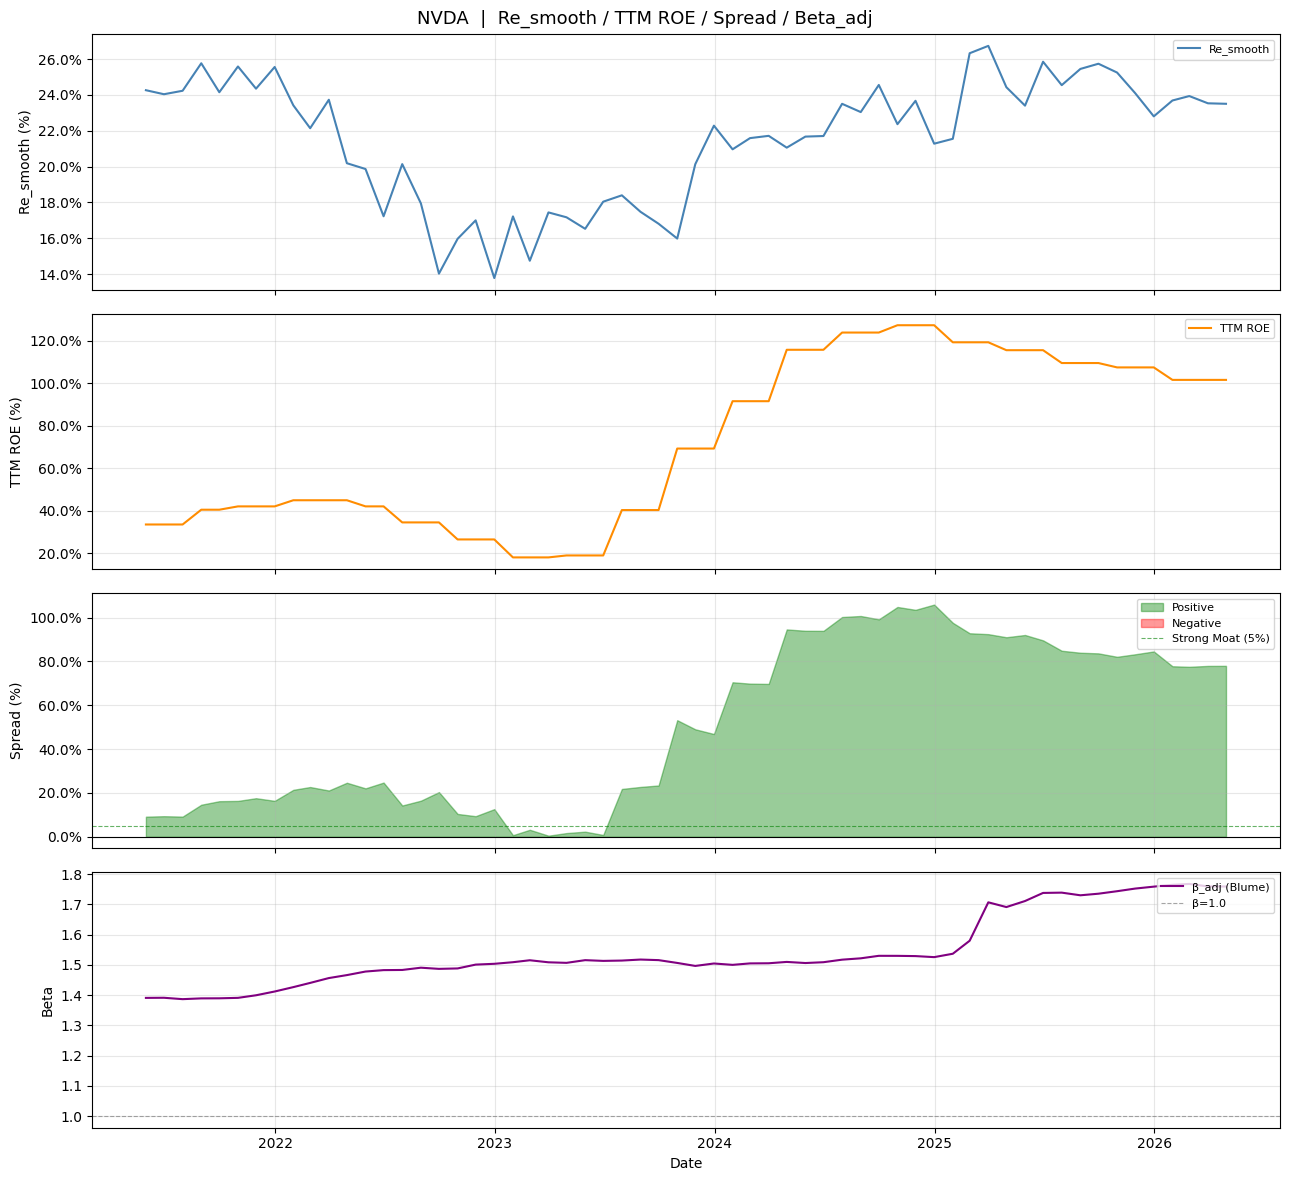


[GOOG]
  TTM ROE 최신: 2025-12-31 = 35.7%
  [SKIP] Re_smooth 없음 — DB에 beta_1250 데이터 확인 필요

[AAPL]
  TTM ROE 최신: 2025-12-27 = 152.0%
      date  beta_adj  Re_smooth      roe  rim_spread_smooth
2026-01-31  1.158212   0.168520 1.520213           1.351693
2026-02-28  1.153934   0.168469 1.520213           1.351745
2026-03-31  1.146143   0.166969 1.520213           1.353244


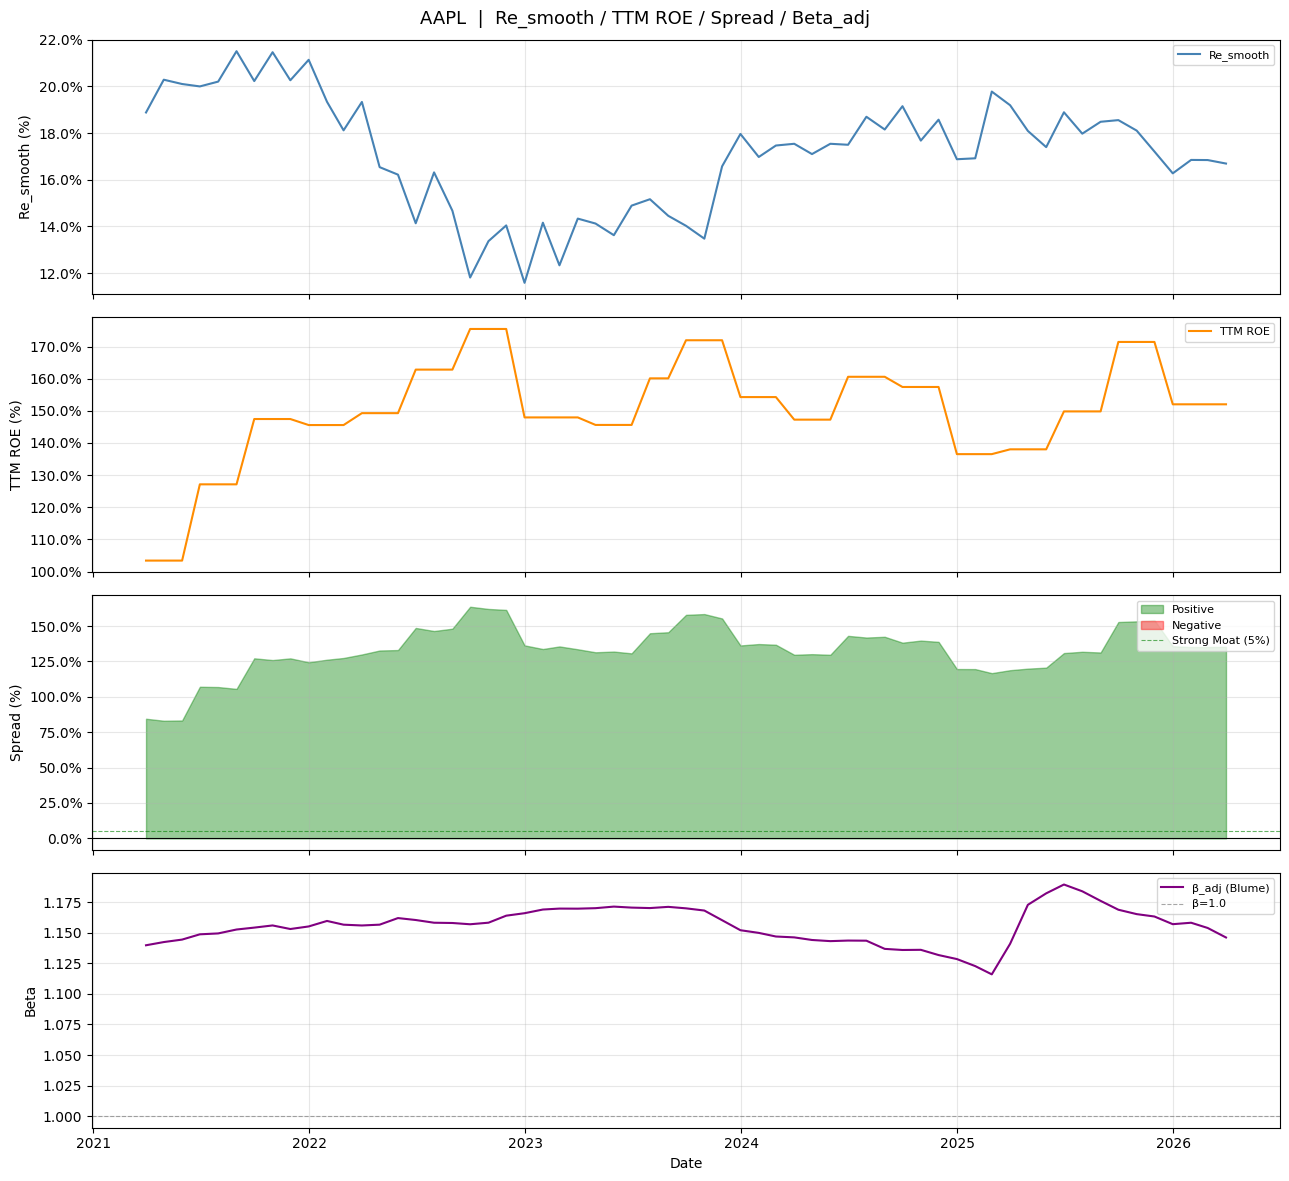


[MSFT]
  TTM ROE 최신: 2025-12-31 = 34.4%
      date  beta_adj  Re_smooth      roe  rim_spread_smooth
2026-01-31  1.094516   0.161337 0.343908           0.182571
2026-02-28  1.098696   0.162084 0.343908           0.181823
2026-03-31  1.092485   0.160987 0.343908           0.182920


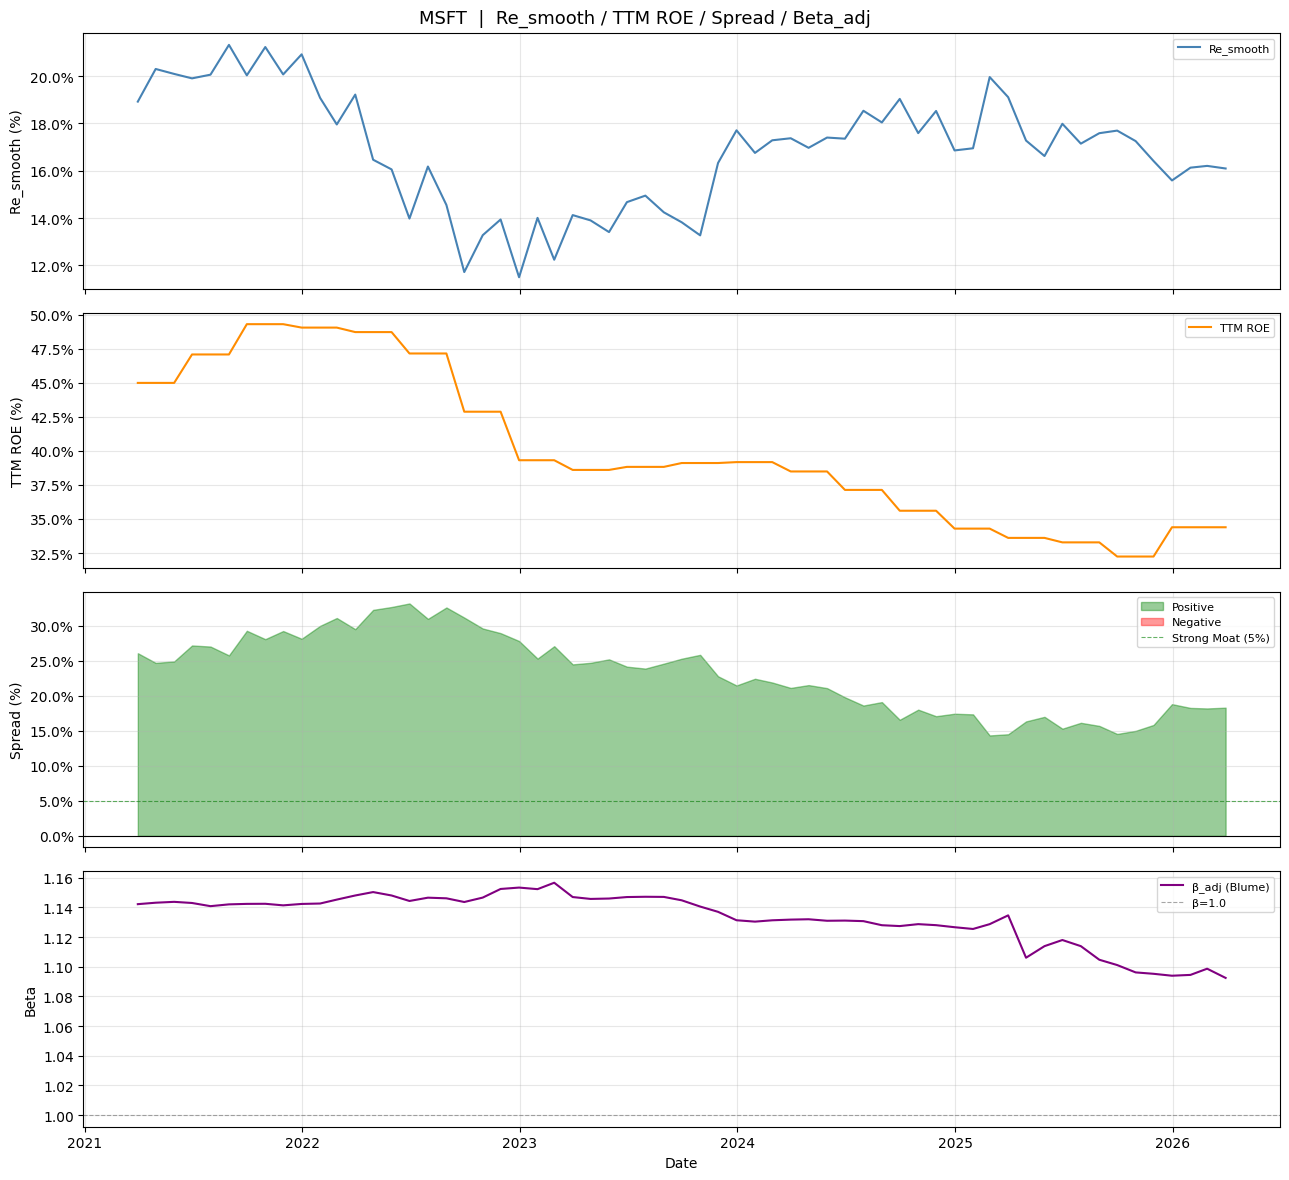


[AMZN]
  TTM ROE 최신: 2025-12-31 = 22.3%
  [SKIP] Re_smooth 없음 — DB에 beta_1250 데이터 확인 필요

[META]
  TTM ROE 최신: 2025-12-31 = 30.2%
  [SKIP] Re_smooth 없음 — DB에 beta_1250 데이터 확인 필요

[TSLA]
  TTM ROE 최신: 2025-12-31 = 4.9%
  [SKIP] Re_smooth 없음 — DB에 beta_1250 데이터 확인 필요

[완료]


In [18]:
all_spread = []

for ticker in TICKERS:
    print(f"\n{'='*55}\n[{ticker}]")

    # ① TTM ROE 계산
    roe_raw = compute_ttm_roe(ticker)
    if roe_raw.empty:
        print(f'  [SKIP] TTM ROE 없음'); continue
    print(f'  TTM ROE 최신: {roe_raw.iloc[-1]["date"].date()} = '
          f'{roe_raw.iloc[-1]["roe_ttm"]*100:.1f}%')

    # ② 월말 ffill
    roe_monthly = roe_to_monthly(roe_raw)

    # ③ 해당 티커 Re_smooth
    re_tk = re_monthly[re_monthly['ticker'] == ticker].copy()
    if re_tk.empty:
        print(f'  [SKIP] Re_smooth 없음 — DB에 beta_1250 데이터 확인 필요'); continue

    # ④ 스프레드 계산
    spread = compute_spread(re_tk, roe_monthly)
    valid  = spread.dropna(subset=['Re_smooth','roe','rim_spread_smooth'])
    if valid.empty:
        print(f'  [WARN] 스프레드 계산 결과 없음'); continue

    print(valid[['date','beta_adj','Re_smooth','roe','rim_spread_smooth']].tail(3)
          .to_string(index=False))

    # ⑤ 시각화
    plot_spread(spread, ticker)
    all_spread.append(spread)

print('\n[완료]')


### STEP 4. 역사적 평균 스프레드 해자 분류

In [ ]:
if all_spread:
    full_spread = pd.concat(all_spread, ignore_index=True)
    moat = classify_moat(full_spread)
    display(moat)
    for grade, label in [('strong_economic_moat','Strong (≥5%)'),
                          ('middle','Middle (0~5%)'), ('weak','Weak (<0%)')]:
        g = moat[moat['moat_grade']==grade]
        print(f'{label:15s} ({len(g)}개): {g["ticker"].tolist()}')
else:
    print('[INFO] 데이터 없음')


### STEP 5. DB 저장 (Re_smooth / roe_ttm / rim_spread_smooth)

In [ ]:
if all_spread:
    save_cols = {
        'Re_smooth':         'Re_smooth',
        'roe':               'roe_ttm',
        'rim_spread_smooth': 'rim_spread_smooth',
    }
    rows_to_save = []
    for _, r in full_spread.iterrows():
        d = r['date']
        t = r['ticker']
        for col, ind_name in save_cols.items():
            if col in r.index and not pd.isna(r[col]):
                rows_to_save.append({'date':d,'ticker':t,
                                     'indicator':ind_name,'value':r[col]})

    long_df = pd.DataFrame(rows_to_save)
    n = upsert_long_df(long_df)
    print(f'[OK] DB 저장 완료: {n:,} rows → {TABLE_RESULT}')
else:
    print('[INFO] 저장할 데이터 없음')
